In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  print("Num GPUs Available: ", len(gpus))
  for gpu in gpus:
      print("GPU:", gpu.name)
else:
  print("No GPU found")

Num GPUs Available:  1
GPU: /physical_device:GPU:0


In [20]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')
tf.test.is_gpu_available()

True

In [1]:
import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:

# Common parameters
BATCH_SIZE   = 32
IMG_SIZE     = (224, 224)
DATA_DIR     = r"C:\Users\User\Downloads\Skin-disease-dataset\train"
SEED         = 42           # keeps split reproducible
VAL_SPLIT    = 0.20         # 80 % train, 20 % validation

datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    brightness_range=[0.9, 1.1],
    fill_mode='nearest',
    validation_split=VAL_SPLIT      # ← **key line**
)



training_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',              # ← **80 % of images**
    shuffle=True,
    seed=SEED
)

test_set = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',            # ← **20 % of images**
    shuffle=True,
    seed=SEED
)


Found 38750 images belonging to 6 classes.
Found 9682 images belonging to 6 classes.


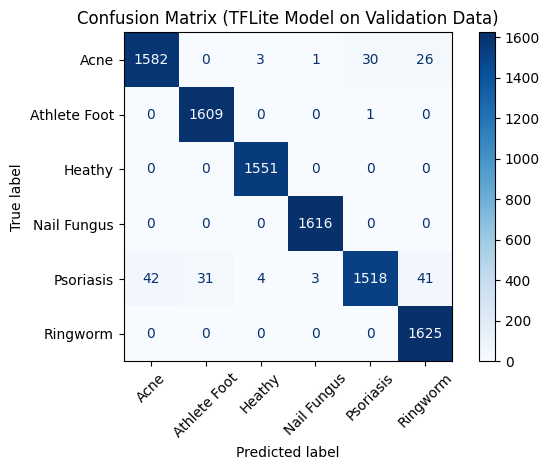

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# --- 1. Load the TFLite Model ---
interpreter = tf.lite.Interpreter(model_path="299-model-test-v5.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# --- 2. Set Up Test Data (already defined by you) ---
# test_set is already created using validation_split=0.2

# --- 3. Run Inference on test_set ---
Y_true = []
Y_pred = []

# Go through all batches
for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]
    
    for img, true_label in zip(x_batch, y_batch):
        img = np.expand_dims(img.astype(np.float32), axis=0)  # (1, 224, 224, 3)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        pred_label = np.argmax(output[0])
        true_label = np.argmax(true_label)

        Y_pred.append(pred_label)
        Y_true.append(true_label)

    # Break when all validation samples are processed
    if (i + 1) * test_set.batch_size >= test_set.samples:
        break

# --- 4. Plot Confusion Matrix ---
labels = list(test_set.class_indices.keys())

cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (TFLite Model on Validation Data)")
plt.tight_layout()
plt.show()


Processed image: True=1, Pred=1
Processed image: True=1, Pred=1
Processed image: True=1, Pred=1
Processed image: True=3, Pred=3
Processed image: True=0, Pred=0
Processed image: True=2, Pred=2
Processed image: True=2, Pred=2
Processed image: True=2, Pred=2
Processed image: True=4, Pred=4
Processed image: True=0, Pred=0
Processed image: True=0, Pred=0
Processed image: True=1, Pred=1
Processed image: True=5, Pred=5
Processed image: True=2, Pred=2
Processed image: True=0, Pred=0
Processed image: True=3, Pred=3
Processed image: True=1, Pred=1
Processed image: True=5, Pred=5
Processed image: True=5, Pred=5
Processed image: True=4, Pred=1
Processed image: True=4, Pred=4
Processed image: True=3, Pred=3
Processed image: True=0, Pred=0
Processed image: True=2, Pred=2
Processed image: True=2, Pred=2
Processed image: True=4, Pred=4
Processed image: True=0, Pred=0
Processed image: True=4, Pred=4
Processed image: True=2, Pred=2
Processed image: True=1, Pred=1
Processed image: True=2, Pred=2
Processe

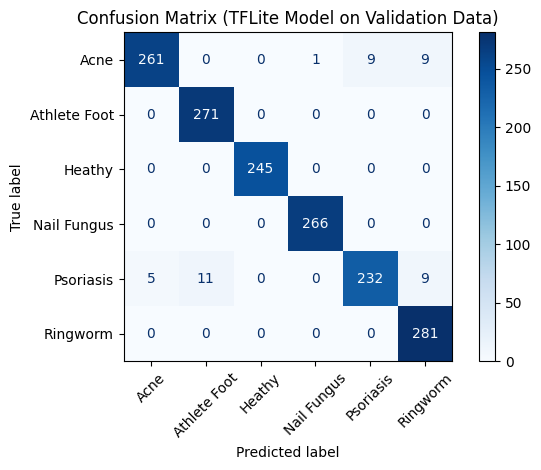

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# --- 1. Load the TFLite Model ---
interpreter = tf.lite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# --- 2. Set Up Test Data (already defined by you) ---
# test_set is already created using validation_split=0.2

Y_true = []
Y_pred = []

input_scale, input_zero_point = input_details[0]['quantization']

for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]

    for img, true_label in zip(x_batch, y_batch):
        img = np.expand_dims(img, axis=0).astype(np.float32)

        # Quantize input image
        img = (img / input_scale + input_zero_point).astype(np.int8)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        pred_label = np.argmax(output[0])
        true_label = np.argmax(true_label)

        Y_pred.append(pred_label)
        Y_true.append(true_label)
        print(f"Processed image: True={true_label}, Pred={pred_label}")
    print(f"Completed batch {i+1}/{len(test_set)}")

    # Stop after 100 batches
    if i + 1 >= 50:
        print("🛑 Stopping after 50 batches")
        break


# --- 4. Plot Confusion Matrix ---
labels = list(test_set.class_indices.keys())

cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (TFLite Model on Validation Data)")
plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# Load quantized TFLite model
interpreter = tf.lite.Interpreter(model_path="299_model_dynamic_quant.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

Y_true = []
Y_pred = []

for i in range(len(test_set)):
    x_batch, y_batch = test_set[i]
    
    for img, label in zip(x_batch, y_batch):
        img = np.expand_dims(img.astype(np.float32), axis=0)  # Shape: (1, H, W, C)

        interpreter.set_tensor(input_details[0]['index'], img)
        interpreter.invoke()
        output = interpreter.get_tensor(output_details[0]['index'])

        pred_label = np.argmax(output[0])
        
        if len(label.shape) > 0 and label.shape[-1] > 1:
            true_label = np.argmax(label)
        else:
            true_label = int(label)
        
        Y_pred.append(pred_label)
        Y_true.append(true_label)

    if (i + 1) * test_set.batch_size >= getattr(test_set, 'samples', len(test_set) * test_set.batch_size):
        break

# Confusion matrix
labels = list(getattr(test_set, 'class_indices', {str(i): i for i in range(len(set(Y_true)))}).keys())
cm = confusion_matrix(Y_true, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (TFLite Model on Validation Data)")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

In [6]:
# main model check
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import load_model

# Load the model
model = load_model('299-model-test-v5.h5')

model = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                50240     
                                                                 
 dense_1 (Dense)             (None, 10)                650       
                                                                 
Total params: 50,890
Trainable params: 50,890
Non-trainable params: 0
_________________________________________________________________


In [8]:
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="299-model-test-v5.tflite")
interpreter.allocate_tensors()

# Get tensor details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
tensor_details = interpreter.get_tensor_details()

# Print input layer info
print("🔹 Input Layer:")
for i in input_details:
    print(f"Name: {i['name']}, Shape: {i['shape']}, Type: {i['dtype']}")

# Print output layer info
print("\n🔹 Output Layer:")
for o in output_details:
    print(f"Name: {o['name']}, Shape: {o['shape']}, Type: {o['dtype']}")

# Print all internal tensors (like a raw summary)
print("\n🔍 All Tensors (Ops):")
for t in tensor_details:
    print(f"Index: {t['index']}, Name: {t['name']}, Shape: {t['shape']}, Type: {t['dtype']}")


🔹 Input Layer:
Name: serving_default_mobilenetv2_1.00_224_input:0, Shape: [  1 224 224   3], Type: <class 'numpy.float32'>

🔹 Output Layer:
Name: StatefulPartitionedCall:0, Shape: [1 6], Type: <class 'numpy.float32'>

🔍 All Tensors (Ops):
Index: 0, Name: serving_default_mobilenetv2_1.00_224_input:0, Shape: [  1 224 224   3], Type: <class 'numpy.float32'>
Index: 1, Name: sequential/mobilenetv2_1.00_224/bn_Conv1/FusedBatchNormV3, Shape: [32], Type: <class 'numpy.float32'>
Index: 2, Name: sequential/mobilenetv2_1.00_224/expanded_conv_depthwise_BN/FusedBatchNormV3, Shape: [32], Type: <class 'numpy.float32'>
Index: 3, Name: sequential/mobilenetv2_1.00_224/block_1_expand_BN/FusedBatchNormV3, Shape: [96], Type: <class 'numpy.float32'>
Index: 4, Name: sequential/mobilenetv2_1.00_224/block_1_depthwise_BN/FusedBatchNormV3, Shape: [96], Type: <class 'numpy.float32'>
Index: 5, Name: sequential/mobilenetv2_1.00_224/block_2_expand_BN/FusedBatchNormV3, Shape: [144], Type: <class 'numpy.float32'>
Inde

In [9]:
# Converting to float16

import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model('299-model-test-v5.h5')

# Float16 Quantization for mobile
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert
tflite_model = converter.convert()

# Save the model
with open('299_model_float16_mobile.tflite', 'wb') as f:
    f.write(tflite_model)


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5pyh83dv\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp5pyh83dv\assets


In [17]:
# Dynamic range quantization

import tensorflow as tf

# Load your original Keras model
model = tf.keras.models.load_model('299-model-test-v5.h5')

# Set up the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Apply dynamic range quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_model = converter.convert()

# Save the quantized TFLite model
with open('299_model_dynamic_quant.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Dynamic range quantized model saved as '299_model_dynamic_quant.tflite'")


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpokwja4rg\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpokwja4rg\assets


✅ Dynamic range quantized model saved as '299_model_dynamic_quant.tflite'


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === CONFIG ===
BATCH_SIZE = 1
IMG_SIZE = (224, 224)
DATA_DIR = r"C:\Users\User\Downloads\Skin-disease-dataset\train"
SEED = 42
VAL_SPLIT = 0.20

# === Load model ===
model = tf.keras.models.load_model("299-model-test-v5.h5")

# === Prepare representative dataset ===
rep_datagen = ImageDataGenerator(rescale=1./255, validation_split=VAL_SPLIT)

rep_data = rep_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=False,
    seed=SEED
)

def representative_dataset():
    for i in range(100):
        image, _ = rep_data[i]  # Only use image (shape: (1, 224, 224, 3))
        yield [image.astype(np.float32)]

# === Convert to int8 TFLite ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

# Fully quantized int8 (inputs/outputs too)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# Convert and save
tflite_model = converter.convert()

with open("model_int8.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ TFLite int8 model saved as model_int8.tflite")


Found 38750 images belonging to 6 classes.


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpz6vura_m\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpz6vura_m\assets
C:\Users\User\AppData\Roaming\Python\Python310\site-packages\tensorflow\lite\python\convert.py:766: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


✅ TFLite int8 model saved as model_int8.tflite


In [4]:
interpreter = tf.lite.Interpreter(model_path="model_int8.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:", input_details)
print("Output:", output_details)

Input: [{'name': 'serving_default_mobilenetv2_1.00_224_input:0', 'index': 0, 'shape': array([  1, 224, 224,   3]), 'shape_signature': array([ -1, 224, 224,   3]), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output: [{'name': 'StatefulPartitionedCall:0', 'index': 183, 'shape': array([1, 6]), 'shape_signature': array([-1,  6]), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128]), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [10]:
import os
size = os.path.getsize('299_model_float16_mobile.tflite') / 1024
print(f"Model size: {size:.2f} KB")

Model size: 5908.98 KB


In [11]:
import os
size = os.path.getsize('299-model-test-v5.tflite') / 1024
print(f"Model size: {size:.2f} KB")

Model size: 11740.53 KB


In [18]:
import os

size = os.path.getsize('299_model_dynamic_quant.tflite') / 1024
print(f"📉 Compressed model size: {size:.2f} KB")


📉 Compressed model size: 3223.13 KB


In [11]:
import os
size = os.path.getsize('model_int8.tflite') / 1024
print(f"Model size: {size:.2f} KB")

Model size: 3421.41 KB


In [ ]:
import os
size = os.path.getsize('299-model-test-v5.h5') / 1024
print(f"Model size: {size:.2f} KB")

Model size: 36186.66 KB
